In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/kaggle/input/datasets/himanshunakrani/iris-dataset/iris.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df.sample()

,sepal_length,sepal_width,petal_length,petal_width,species
2,4.7,3.2,1.3,0.2,setosa


In [5]:
# split the data into make X and y
X = df.iloc[:,:4]
y = df.iloc[:,4]

In [6]:
# train-test-split
from sklearn.model_selection import train_test_split
X_train, X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [7]:
# shape of X_train
X_train.shape

(120, 4)

In [8]:
# 2. Baseline (NO PCA)
# =========================
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 3)

In [9]:
# Fit knn on train data
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [10]:
import time
start = time.time()
y_pred = knn.predict(X_test)
print("Time without PCA:", time.time() - start)

Time without PCA: 0.0047245025634765625


In [11]:
from sklearn.metrics import accuracy_score
print("Accurcy without PCA:",accuracy_score(y_test, y_pred))

Accurcy without PCA: 1.0


# With PCA

In [12]:
# =========================
# Scale data (IMPORTANT)
# =========================

# Step 1: Standardise the data with Standard Scaler. 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [13]:
#fit scaler on X_train and X_test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
# =========================
# Apply PCA
# =========================
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [18]:
# =========================
# 6. Train again (WITH PCA)
# =========================
knn = KNeighborsClassifier(n_neighbors=3)

start = time.time()
knn.fit(X_train_pca, y_train)
y_pred = knn.predict(X_test_pca)
print("Time WITH PCA:", time.time() - start)

print("Accuracy WITH PCA:", accuracy_score(y_test, y_pred))

Time WITH PCA: 0.0056493282318115234
Accuracy WITH PCA: 0.9333333333333333


In [14]:
# =========================
# Find optimal components
# =========================
from sklearn.decomposition import PCA
# Let's use PCA
pca = PCA()
# pca = PCA(n_components = 100)
pca.fit(X_train_scaled)

PCA()

In [19]:
variance = np.cumsum(pca.explained_variance_ratio_)
#variance

In [20]:
# choose threshold
optimal_k = np.argmax(variance >= 0.95) + 1
print("Optimal k (95% variance):", optimal_k)

Optimal k (95% variance): 2


In [21]:
X_train_scaled.shape

(120, 4)

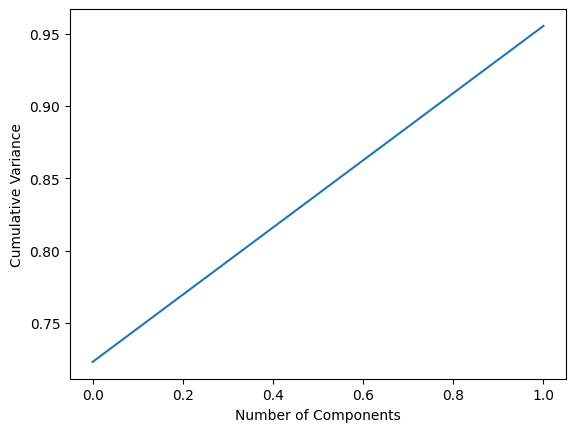

In [22]:
import matplotlib.pyplot as plt
plt.plot(variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.show()